In [ ]:
#1. PCA(주성분 분석), 펼쳐저 보이게 누름, 시각화


import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
#pandas.read_csv() 동일하게 데이터를 불러오는 방법이나, 어디서 데이터를 가져오느냐와 어떤 혀애로 불러오느냐가 다름
#load_iris는 사이킷런 안에 연습용 데이터인거임
from sklearn.decomposition import PCA #PCA 객체 임폴트

iris = load_iris()
data = iris.data
target = iris.target #정답 y
target_names = iris.target_names # 라벨 이름 배열
data.shape #현재 4개의 컬럼. 이걸 2개의 컬럼으로 압축(컬럼 삭제가 아님)

(150, 4)

In [ ]:
pca = PCA(n_components=2) #2개의 주성분으로 변환
data_pca = pca.fit_transform(data) #PCA 수행
data_pca
#2개의 컬럼으로 줄어들었다. 컬럼이름 component1, component2
#4개에서 2개의 컬럼으로 줄어들었으니 컬럼이름 당연히 모름..

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [ ]:
pca_df = pd.DataFrame(data_pca, columns = ['PCA1', 'PCA2'])
pca_df['target'] = target
pca_df.head(5)

#예로, 첫번째 데이터 5.1, 3.5, 1.4, 0.2이었는데, PCA 통해 -2.684126, 0.319397로 바뀜
#그렇게 해도 정답은 안바뀜

,PCA1,PCA2,target
0,-2.684126,0.319397,0
1,-2.714142,-0.177001,0
2,-2.888991,-0.144949,0
3,-2.745343,-0.318299,0
4,-2.728717,0.326755,0


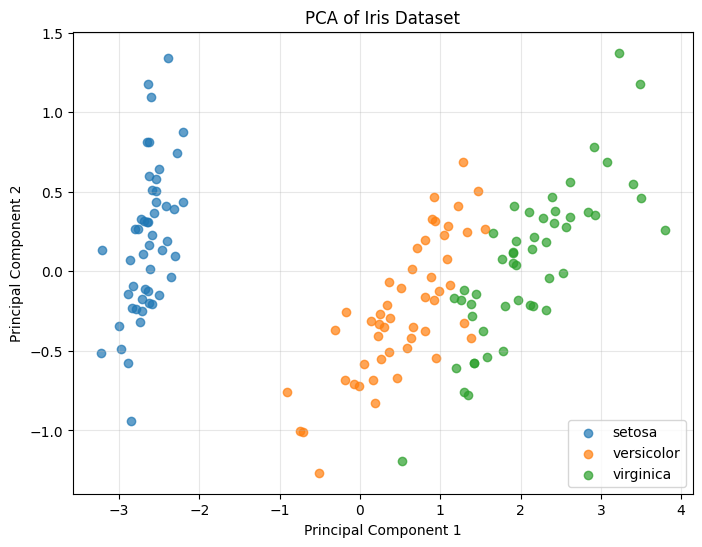

In [ ]:
#PCA 시각화
plt.figure(figsize=(8, 6))
for i, target_name in enumerate(target_names):
#enumerate() : 리스트의 인덱스와 값을 동시에 꺼냄.
#target_names = ['setosa', 'versicolor', virginica']
#이면,       i =[ 0,         1,           2        ]로 출력
    subset = pca_df[pca_df['target']==i]
#pca_df에서 target이 i인 행만 뽑아 -> 품종별로 따로 데이터 뽑기
    plt.scatter(subset['PCA1'], subset['PCA2'], label=target_name, alpha=0.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()


In [ ]:
import plotly.express as px
from sklearn.datasets import load_iris
import pandas as pd

#데이터 불러오기
iris = load_iris()
data = iris.data
target = iris.target
target_names = iris.target_names

#Dataframe 만들기
df = pd.DataFrame(data, columns=iris.feature_names)
df['species'] = [target_names[i] for i in target]

fig = px.scatter_3d(
    df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    z='petal length (cm)',
    color='species',
    symbol='species',
    size='petal width (cm)',
    hover_data=['petal width (cm)'],
    title='Iris Dataset 4D Visualization (species-based colors)'
)

fig.show()


In [ ]:
#Kmeans

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names) #iris 데이터를 pandas 데이터프레임 형태로 변환
data['target'] = iris.target #원본 데이터에 정답(품종 라벨)을 새 컬럼으로 추가, 나중에 실제 품종과 kmeans그룹 비교 가능

kmeans = KMeans(n_clusters=3, random_state=42) #그룹 3개로 묶을거다
data['cluster'] = kmeans.fit_predict(data.iloc[:,:-1]) #행, 열 > 마지막 열(-1)빼고 나머지 열만 선택

In [ ]:
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,0
146,6.3,2.5,5.0,1.9,2,2
147,6.5,3.0,5.2,2.0,2,0
148,6.2,3.4,5.4,2.3,2,0


In [ ]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data.iloc[:,:-2]) # target, cluster 빼고 4개를 두개로 바꾼거
data_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [ ]:
data['pca_x'] = data_pca[:, 0]
data['pca_y'] = data_pca[:, 1]

In [ ]:
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,-2.728717,0.326755
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,0,1.944110,0.187532
146,6.3,2.5,5.0,1.9,2,2,1.527167,-0.375317
147,6.5,3.0,5.2,2.0,2,0,1.764346,0.078859
148,6.2,3.4,5.4,2.3,2,0,1.900942,0.116628


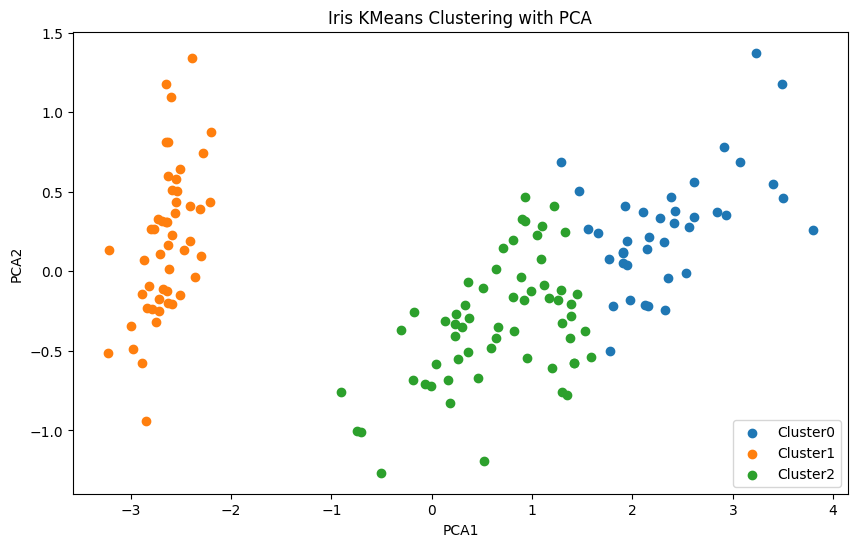

In [ ]:
#클러스터 마다 플랏
plt.figure(figsize=(10, 6))
for cluster in range(3) : #3개의 클러스트가 있으니 세번 반복하면서 각각의 클러스터를 따로 그림
  clustered_data = data[data['cluster'] == cluster] #cluster 번호가 현재 cluster 값인 행만 선택해(예.clster=1, 군집 1번에 속한 데이터만 꺼내옴)
  plt.scatter(clustered_data['pca_x'], clustered_data['pca_y'], label=f'Cluster{cluster}') #산점도 그리기

plt.title("Iris KMeans Clustering with PCA")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.show()


#군집을 통해서 패턴, 특징, 구조를 발견하는게 핵심
#예로들어 고객데이터면 고객을 자동으로 묶어서 비슷한 소비 패턴을 가진 고객군을 3가지로 나눔


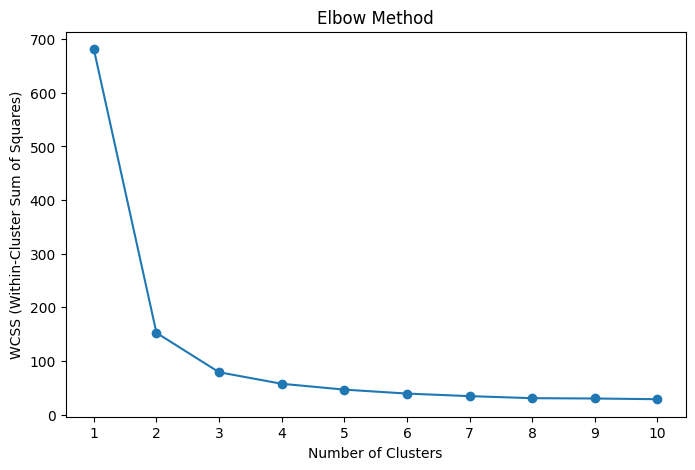

In [ ]:
#최적의 군집 수 결정하기 - 엘보우 기법 (클럿터 내 오차 제곱합, SSE 이 크게 줄어들다가 완만하게 꺾이는 부분의 K 선정)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

#dataframe = 표 생성함수
#iris.data = load_iris()데이터 중 숫자형 데이터만 들어있는 부분
#column=iris.feature_names : 열이름

max_k=10 #최대 몇개의 클러스터까지 실험해볼지 정한 값 - 응집도 계산
wcss = [] #WCSS를 저장할 빈 리스트 만들기, 각 클러스터 안에서 점들이 중심에서 얼마나 가까운가의 합 > 응집도
for k in range(1, max_k+1) : # K를 1에서 10까지 바꿔가며 K-Mneas여러번 실행(1일때 성능은?, 2일때 성능은?~)
  kmeans = KMeans(n_clusters=k, random_state=42) #KMeans 객체 만들기. 이번 반복에서의 군집 수 지정
  kmeans.fit(data) #학습(클러스터링) 수행
  wcss.append(kmeans.inertia_) #inertia_ : KMeans 모델이 자동으로 계산한 각 클러스터의 내부 거리 합(WCSS)
  #클러스터 내 점들이 중심에서 얼마나 가까운지의 합 > 응집도가 높일 수록 (값이 작을수록)군집이 잘됨

  #왜 응집도가 높으면 값이 작은거냐
  #클러스터 안의 점들이 서로 가까이 몰려있으면, 중심과 거리 짧음. 제곱값 작음. 합계 WCSS 작음 >> 응집도 높음 (잘뭉쳐있다)
  #클러스터 안의 점들이 서로 흩어져 있으면, 중심에서 멀리 떨어진 점들이 많음, 거리 제곱값이 커짐, 합계 WCSS 큼 >> 응집도 낮다 (잘 안 뭉쳐있다)

  #WCSS 값이 작을 수록 > 점들이 중심에 더 가까이 모여있음 >> 응집도 높음
  #WCSS 값이 클 수록 > 점들이 중심에서 멀리 흩어져 있음 >> 응집도 낮음


plt.figure(figsize=(8,5))
plt.plot(range(1, max_k+1), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, max_k+1))
plt. show()

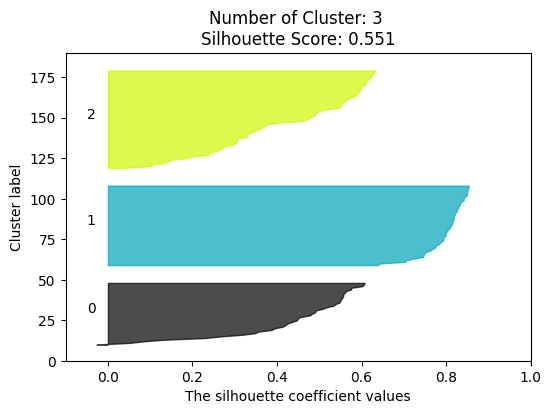

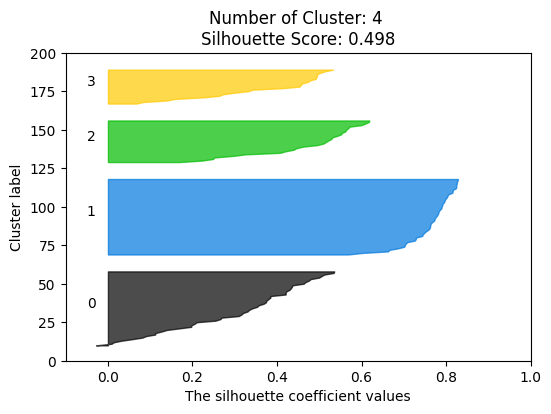

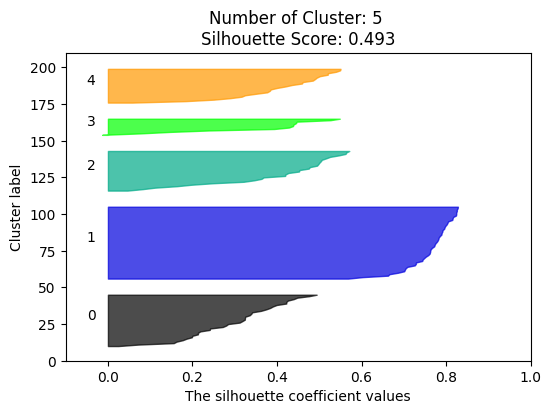

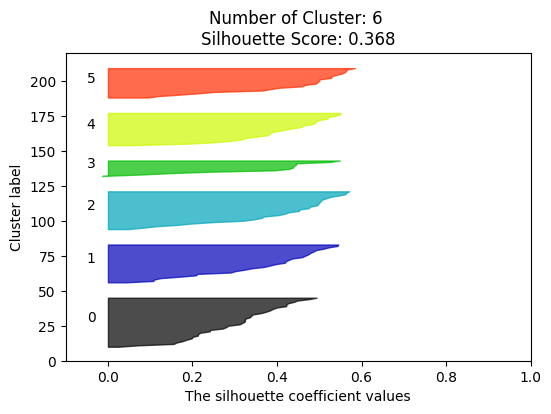

In [ ]:
#최적의 군집 수 결정하기 - 실루엣 기법 : 응집도와 분리도로부터 실루엣 스코어를 계산하여 가장 값이 클 때의 K산정

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

iris = load_iris()
data = iris.data

# 클러스터 개수
cluster_range = [3, 4, 5, 6]

for n_clusters in cluster_range:  # 각 클러스터 개수에 대해 반복 실행

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(data)

    # 실루엣 점수 함수
    silhouette_avg = silhouette_score(data, cluster_labels)  # 평균 실루엣 점수를 계산
    sample_silhouette_values = silhouette_samples(data, cluster_labels)  # 각 데이터 포인트의 실루엣 계수 계산

    # 실루엣 플롯을 위한 그래프 설정
    fig, ax = plt.subplots(figsize=(6, 4))
    y_lower = 10  # y축에서 시작하는 위치를 초기화 (10부터 시작)

    for i in range(n_clusters):  # 각 클러스터에 대해 반복
        # 클러스터 i의 실루엣 계수를 추출
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]  # 클러스터 i에 속한 데이터의 실루엣 값만 선택
        ith_cluster_silhouette_values.sort()  # 실루엣 계수를 정렬

        size_cluster_i = ith_cluster_silhouette_values.shape[0]  # 클러스터 i의 데이터 포인트 개수 계산
        y_upper = y_lower + size_cluster_i  # y_upper: 해당 클러스터가 끝나는 위치 계산

        # 클러스터 색상
        color = cm.nipy_spectral(float(i) / n_clusters)  # 클러스터별로 다른 색상을 지정
        # 클러스터 실루엣 계수 막대 그래프 그리기
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),  # y축 범위 설정
            0,  # x축에서 시작점 (0)
            ith_cluster_silhouette_values,  # 실루엣 계수를 x축에 표시
            facecolor=color,  # 채우기 색상
            edgecolor=color,  # 테두리 색상
            alpha=0.7,  # 투명도 설정
        )
        # 클러스터 번호
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))  # 클러스터 중앙에 번호 표시

        y_lower = y_upper + 10  # 다음 클러스터 y_lower를 갱신 (10 클러스터 간 간격)

    ax.set_title(f"Number of Cluster: {n_clusters} \nSilhouette Score: {silhouette_avg:.3f}")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(data) + (n_clusters + 1) * 10])
    plt.show()


In [ ]:
#KMeans : 최적의 k를 구해야함
#실루엣, 엘보우 돌려봐야함
#최적 k를 구하면 kmeans 학습
#학습된 kmeans로 데이터 clustering 라벨링
#시각화


SyntaxError: positional argument follows keyword argument (ipython-input-4264792725.py, line 16)

Cluster Centers (Centroids):
[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]
Wninertia (WCSS) : 78.85566582597727


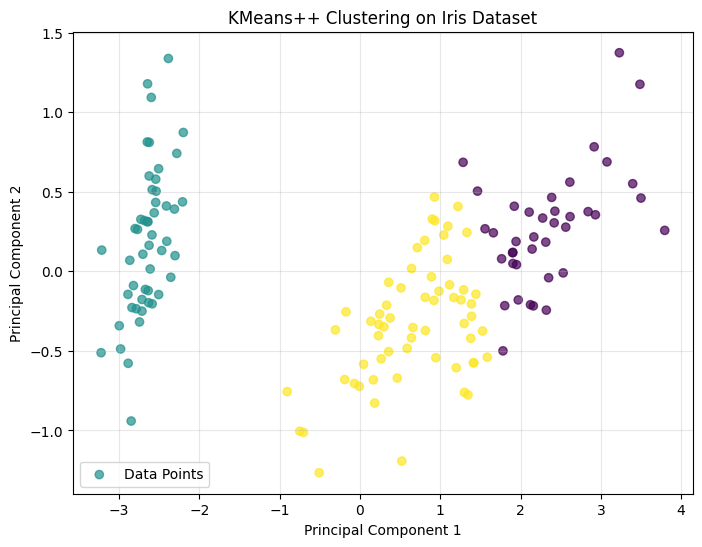

In [ ]:
#KMeans++

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

iris = load_iris()
data = iris.data

# KMeans++ 클러스터링
kmeans = KMeans(n_clusters=3, init = 'k-means++', random_state=42) #kmeans++
cluster_labels = kmeans.fit_predict(data)

print("Cluster Centers (Centroids):")
print(kmeans.cluster_centers_) # 클러스터 중심 출력
print("Wninertia (WCSS) :", kmeans.inertia_) #WCSS 값 출력

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

plt.figure(figsize = (8,6))
plt.scatter(data_pca[:,0], data_pca[:, 1], c=cluster_labels, cmap = 'viridis', alpha=0.7, label='Data Points')
plt.title("KMeans++ Clustering on Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#Kmeans 파생변수

import numpy as np #숫자용 계산기
import pandas as pd #행열 나타내기
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
#k-means로 비슷한 패턴을 그룹화하고,decision tree로 그 패턴을 설명하는 변수 만들어 냄. (데이터를 더 잘 설명하는 파생변수 생성)
#k-means 비지도학습(정답x), Decision tree 지도학습(정답o)
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split


cancer = load_breast_cancer()
data = pd.DataFrame(cancer.data, columns = cancer.feature_names)
target = cancer.target


In [ ]:
data

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
len(target[target==0]), len(target[target==1])

(212, 357)

In [ ]:
#KMeans 파생 변수 없이 학습

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=42, stratify=target)
#data :X값, target : y값, test_size = 0.3 전체 데이터 중 30%를 테스트용으로 쓰겠다(70%훈련, 30%테스트),
#stratify 클래스 비율을 맞춰서 나누는 옵션 -> 안쓰면 ? test세트가 한쪽으로 치우칠수있다
#쉽게 : 훈련용, 시험용 데이터를 비슷한 구성으로 나눠줘
model_without_kmeans = DecisionTreeClassifier(random_state=42) #파생변수 업이 결정트리로 확인
model_without_kmeans.fit(X_train, y_train)

y_pred_without_kmeans = model_without_kmeans.predict(X_test) #훈련끝난 모델이, 시험용 데이터(x_test)로 예측
f1_without_kmeans = f1_score(y_test, y_pred_without_kmeans, average='weighted')
#f1_score:모델의 성능을 평가하는 점수(0~1)
#average='weighted' : 가중치 두기, 데이터가 많은 클래스는 조금 더 비중 두고 계산
print(f"F1 Score: {f1_without_kmeans:.4f}")


F1 Score: 0.9181


In [ ]:
# KMeans 파생변수 추가

kmeans = KMeans(n_clusters=2, random_state=42) #두개의 그룹으로 나눠라
kmeans_labels = kmeans.fit_predict(data) #데이터를 학습시키고, 각 데이터가 어떤 그룹에 속하는지 예측
#fit_predict : 학습 + 바로 결과 돌려주기

data_with_kmeans = data.copy() #원본 데이터를 복사해 새 데이터프레임 만들기, 파생변수 추가할 안전한 복사본 만들기
data_with_kmeans['kmeans_cluster'] = kmeans_labels
#새로운 열 & 이름 > 각 kmeans_labels에 속한 그룹 번호를 넣는다

X_train, X_test, y_train, y_test = train_test_split(data_with_kmeans, target, test_size=0.3, random_state=42,stratify = target)

model_with_kmeans = DecisionTreeClassifier(random_state=42)
model_with_kmeans.fit(X_train, y_train)

y_pred_with_kmeans = model_with_kmeans.predict(X_test)
f1_with_kmeans = f1_score(y_test, y_pred_with_kmeans, average='weighted')
print(f"With KMeans Feature F1 Score: {f1_with_kmeans: 4f}")


With KMeans Feature F1 Score:  0.924093


In [ ]:
#[kmeans로 파생변수 만들고 타이타닉 생존 분류코드 짜보기]

import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

titanic = pd.read_csv("titanic.csv")
titanic
data = titanic.iloc[:,2:]
target = titanic.iloc[:,1]


In [ ]:
data = data.select_dtypes(exclude = "object") # 문자형 데이터 빼고, 숫자형 데이터만 남겨
data.fillna(data.mean(), inplace =True) # 데이터 안에 비어있는 값(na)을, 그 열의 평균값으로 채워라



In [ ]:
target

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [ ]:
data

,Pclass,Age,SibSp,Parch,Fare
0,3,22.000000,1,0,7.2500
1,1,38.000000,1,0,71.2833
2,3,26.000000,0,0,7.9250
3,1,35.000000,1,0,53.1000
4,3,35.000000,0,0,8.0500
...,...,...,...,...,...
886,2,27.000000,0,0,13.0000
887,1,19.000000,0,0,30.0000
888,3,29.699118,1,2,23.4500
889,1,26.000000,0,0,30.0000


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=42, stratify=target)

model_without_kmeans = DecisionTreeClassifier(random_state=42)
model_without_kmeans.fit(X_train, y_train)

y_pred_without_kmeans = model_without_kmeans.predict(X_test)
f1_without_kmeans = f1_score(y_test, y_pred_without_kmeans, average='weighted')
print(f"F1 Score: {f1_without_kmeans:.4f}")

F1 Score: 0.6045


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(data)

data_with_kmeans = data.copy()
data_with_kmeans['kmeans_cluster'] = kmeans_labels

X_train, X_test, y_train, y_test = train_test_split(data_with_kmeans, target, test_size = 0.3, random_state=42)

model_with_kmeans = DecisionTreeClassifier(random_state=42)
model_with_kmeans.fit(X_train, y_train)

y_pred_with_kmeans = model_with_kmeans.predict(X_test)
f1_with_kmeans = f1_score(y_test, y_pred_with_kmeans, average='weighted')
print(f"With KMeans Feature F1 Score: {f1_with_kmeans: 4f}")


With KMeans Feature F1 Score:  0.641584
